In [70]:
%run env.ipynb

The Cython extension is already loaded. To reload it, use:
  %reload_ext Cython
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


env.ipynb:13: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  "editable": true,


In [71]:
import pickle
import numpy as np
from jLM.RDME import File as RDMEFile
import jLM

In [72]:
# traj = RDMEFile("yeast_20240424_4_t60minGAE11.1mM.lm")
# rdmePerCompartment = pickle.load(open("/data2/pstats-dummy-mrna.pkl", "rb"))
# odeTraj = pickle.load(open("yeast_20240424_4_t60minGAE11.1mM.lm_ode.pkl", "rb"))
traj = RDMEFile("../../sim/yeast-hybrid-newDnaRt.lm")
rdmePerCompartment = pickle.load(open("../../sim/pstats.pkl", "rb"))
odeTraj = pickle.load(open("../../sim/yeast-hybrid-newDnaRt.lm.pkl", "rb"))

In [73]:
ts,ys = traj.getNumberTrajectory(regex="R.*")

In [74]:
ts,ys2 = traj.getNumberTrajectory(regex="ribosome.+")

In [75]:
def getSegments(ts,ys):
    idxs = np.array([0] + list(np.where(np.diff(ys)!=0)[0]+1) + [ts.size-1])
    state = ys[idxs]
    times = ts[idxs]
    return [(t0,t1) for t0,t1,y in zip(times,times[1:], state) if y==1]

In [76]:
def plotGenes(traj, ax):
    states = ["", "_G4d", "_G4d_G80d"]
    stateNames = ["Free", "Active", "Repressed"]
    def isOff(s):
        return s.endswith(states[2])
    def isOn(s):
        return s.endswith(states[1])
    def isFree(s):
        return not (isOff(s) or isOn(s))
    
    gns = ['DG1', 'DG2', 'DG3', 'DG80', 'DGrep']
    gnLabels = ["G$_1$", "G$_2$", "G$_3$", "G$_{80}$", r"G$_\mathrm{rep}$" ]
    trs = dict()
    for gn in gns:
        trs[gn] = dict()
        for st in states:
            sp = gn+st
            trs[gn][st] = getSegments(*traj.species(sp).getNumberTrajectory())
        
    tMin = min(t[0] for segs in trs.values() for seg in segs.values() for t in seg)
    tMax = max(t[1] for segs in trs.values() for seg in segs.values() for t in seg)
    
    handles = [None]*len(states)
    # colors = sns.color_palette()
    sns.set_palette("colorblind")
    color = sns.color_palette("colorblind", 3) 
    fmt = dict(solid_capstyle='butt', linewidth=16)
    
    for i,(gn, segs) in enumerate(trs.items()):
        for j,(st, name) in enumerate(zip(states,stateNames)):
            for t0,t1 in segs[st]:
                handles[stateNames.index(name)] = ax.plot([t0/60,t1/60],[i,i], color=colors[j], **fmt)[0]
        
    ax.set(yticks=np.arange(len(gns)), yticklabels=gnLabels, xlim=(tMin/60,tMax/60), ylim=(-0.5,len(gns)-0.5), xlabel='t/min')
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width, box.height * 0.9])
    ax.legend(handles, stateNames,loc="lower center", bbox_to_anchor=(0.5,1.05), ncol=3)

In [77]:
sns.set()
sns.set_style("ticks")
sns.set_context("talk")

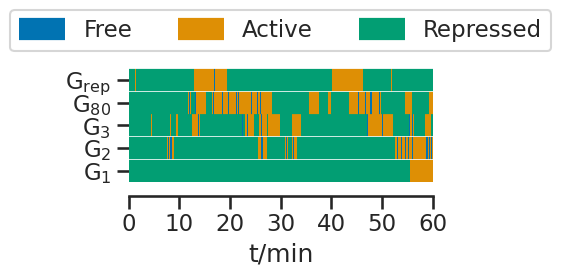

In [96]:
with sns.axes_style("ticks"):
    fig, ax = plt.subplots()
    plotGenes(traj, ax)
    sns.despine(top=True, left=True, right=True,offset=10, trim=True)
    fig.tight_layout(pad=5)
    fig.savefig("gene_expression.png",dpi=300)

In [79]:
odeTs = odeTraj['ts']/60
NAV = 6.022e23*(traj.reg.cytoplasm.volume + traj.reg.nucleoplasm.volume + traj.reg.plasmaMembrane.volume)
odeYs = {n:odeTraj['ys'][:,i]*NAV for i,n in enumerate(odeTraj['names'])}
rdmeYs = dict()

for sp in traj.speciesList:
    ts,ys = sp.getNumberTrajectory()
    rdmeYs[sp.name] = ys
    rdmeTs = ts#/60

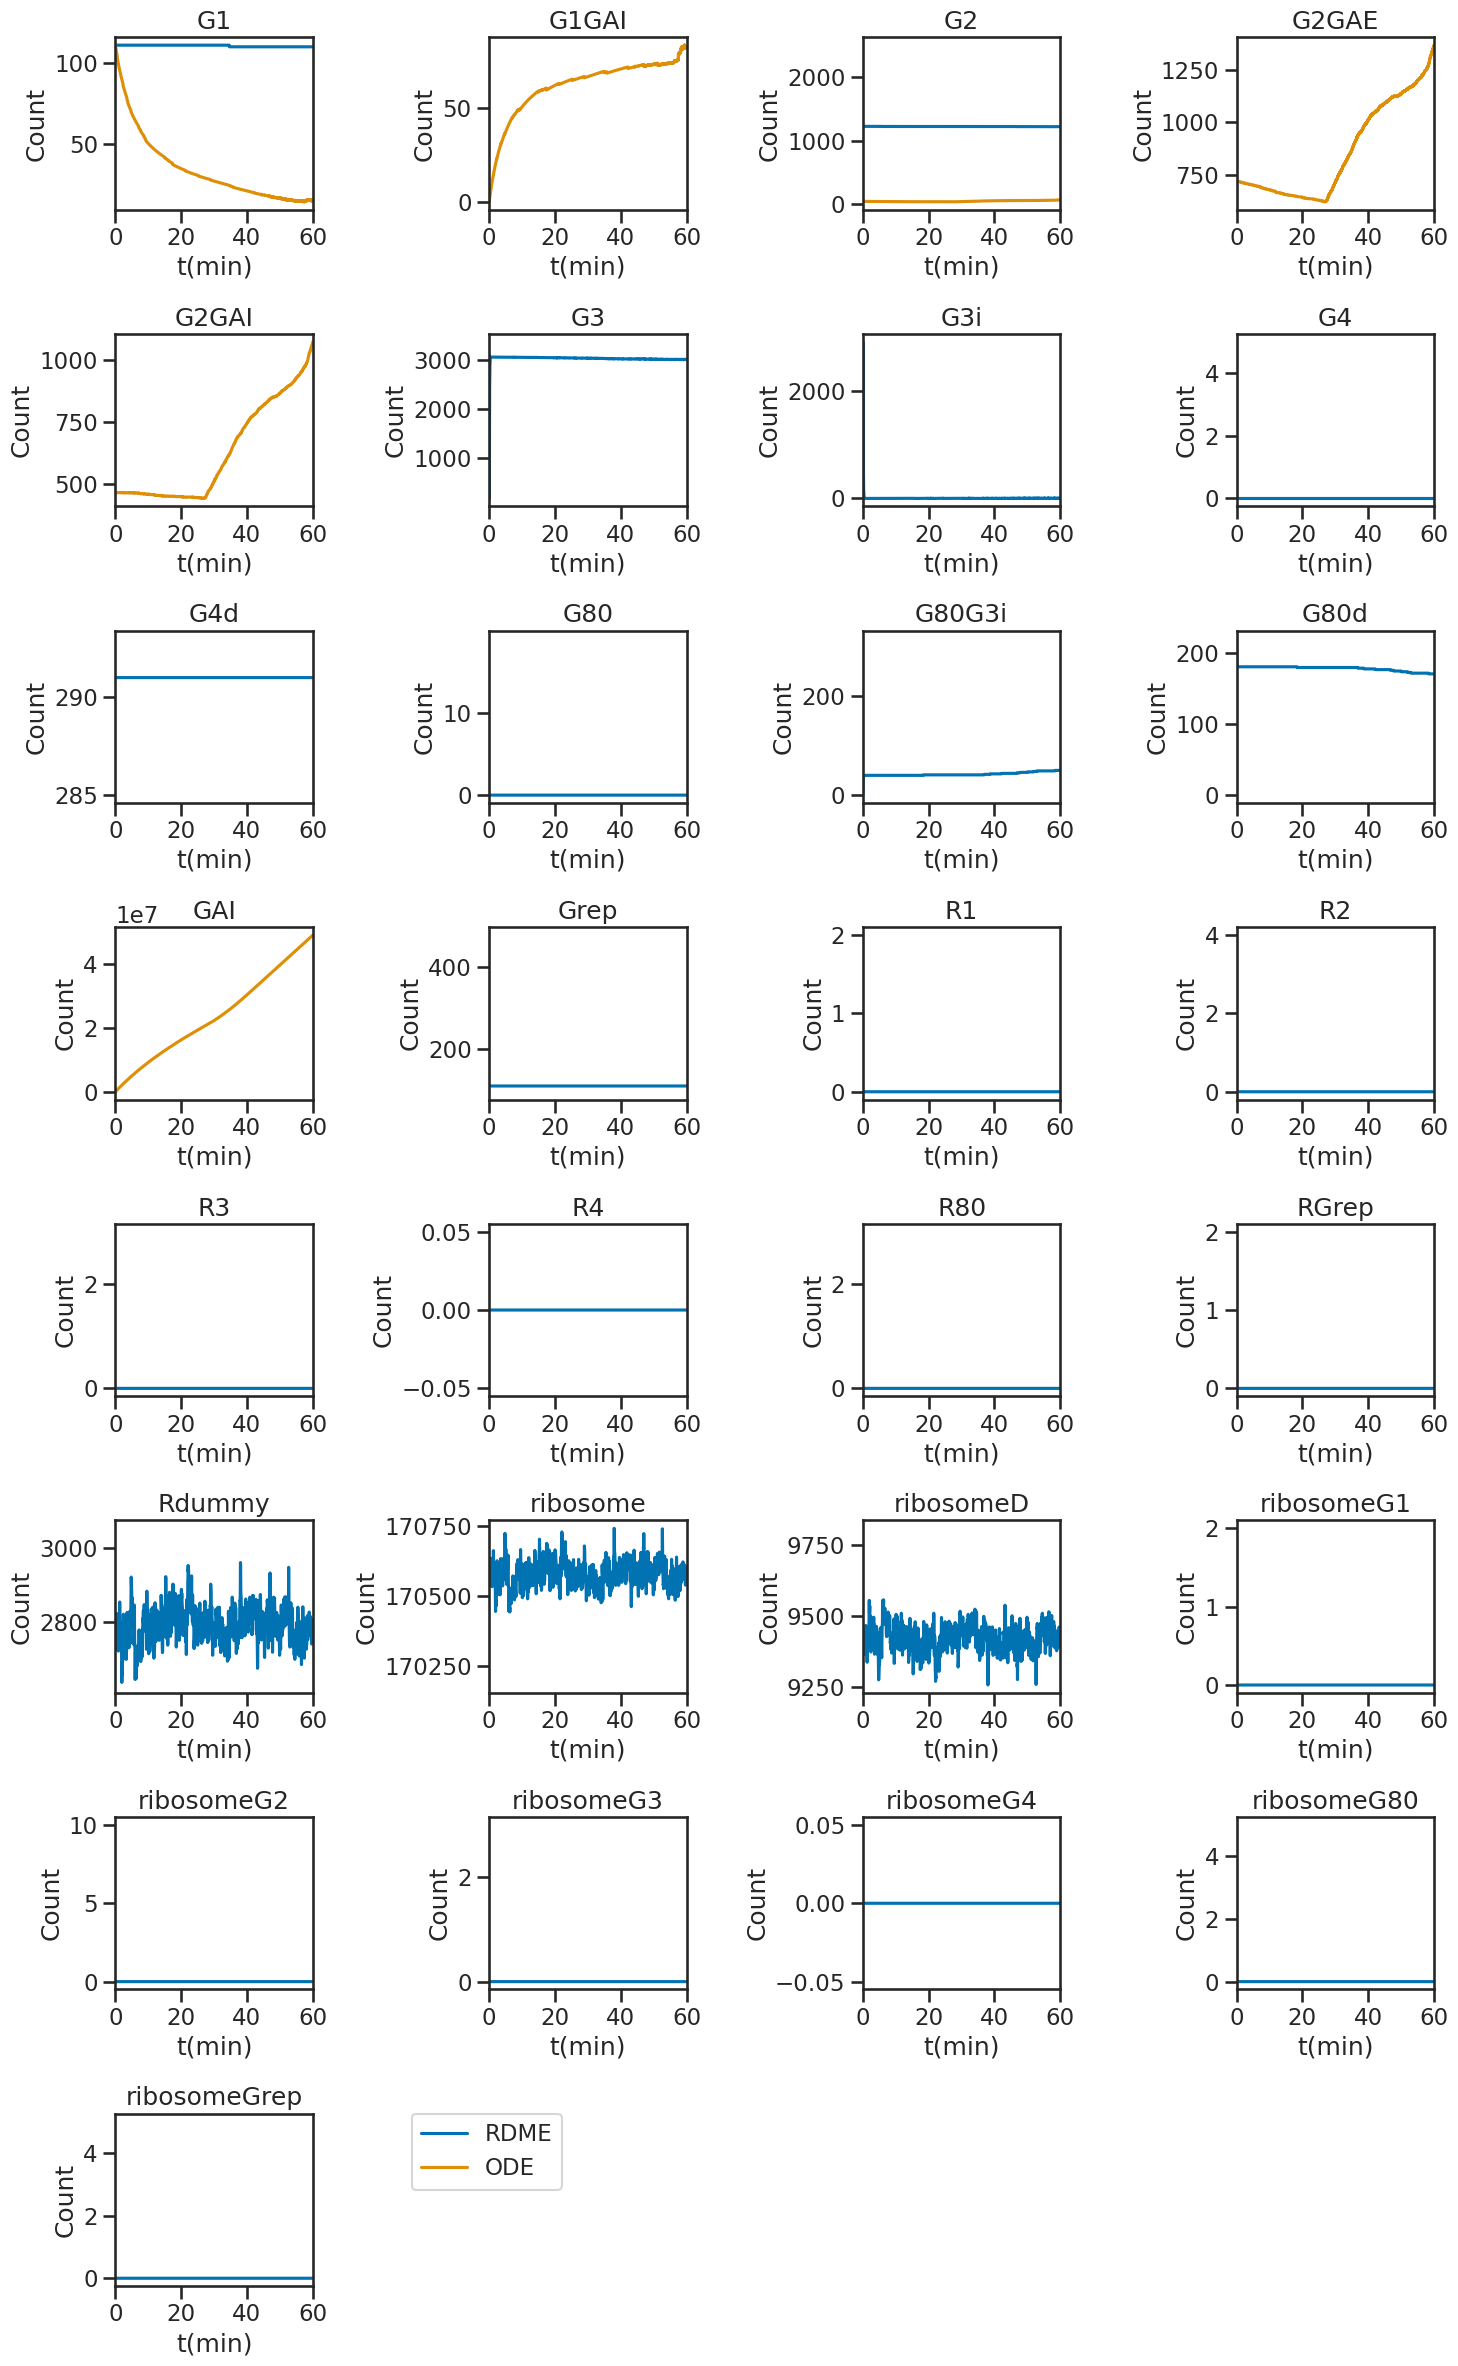

In [80]:
names = sorted(filter(lambda x: x[0]!='D', set(rdmeYs.keys()) | set(odeYs.keys())))
nplots = len(names)
ncols=4
nrows = int(np.ceil(nplots/ncols))

# axargs = dict(xlim=(min(odeTs.min(), rdmeTs.min()), max(odeTs.max(), rdmeTs.max())),
#               xlabel='t/min', ylabel='Count')
axargs = dict(xlim=(min(odeTs.min(), rdmeTs.min()), 60),
              xlabel='t(min)', ylabel='Count', xticks=np.arange(0,61,20))

fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(15,3*nrows))
axs = axs.ravel()
colors = sns.color_palette()
for ax, name in zip(axs, names):
    if name in rdmeYs:
        rdmeHandle = ax.plot(rdmeTs, rdmeYs[name], c=colors[0], label="RDME")[0]
    if name in odeYs:
        odeHandle = ax.plot(odeTs, odeYs[name], c=colors[1], label="ODE")[0]
    ax.set(title=name, **axargs)
    
for i,ax in enumerate(axs):
    if i >= nplots:
        ax.remove()

fig.tight_layout()
        
axs[nplots-1].legend([rdmeHandle, odeHandle], ["RDME", "ODE"], bbox_to_anchor=(1.5, 1), loc=2, borderaxespad=0.)

fig.savefig('all_species_counts.png',dpi=300)

Galactose compare

G2 in total

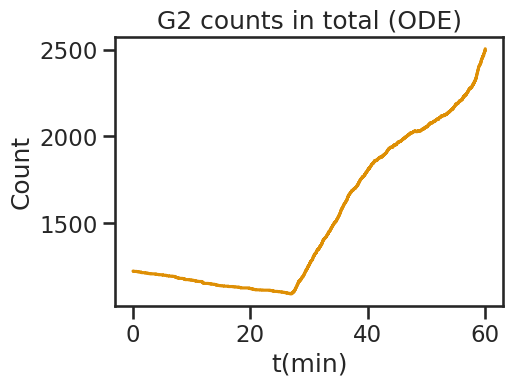

In [101]:
fig, ax = plt.subplots(figsize=(5,3.5))
# draw a plot similiar to previous to show G2+G2GAI + G2GAE in total
selected_names = ['G2', 'G2GAE', 'G2GAI']
totalG2 = np.zeros(odeYs['G2'].shape)
for name in selected_names:
    totalG2 += odeYs[name]
ax.plot(odeTs[:], totalG2[:], c=colors[1])
plt.xlabel('t(min)')
plt.ylabel('Count')
plt.title('G2 counts in total (ODE)')
# ax.plot(odeTs, odeYs[name], c=colors[1], label="ODE")[
fig.savefig('G2_total.png',dpi=300,bbox_inches='tight')

G2 RDME

In [ ]:
fig, ax = plt.subplots(figsize=(5,3.5))
# draw a plot similiar to previous to show G2+G2GAI + G2GAE in total
selected_names = ['G2', 'G2GAE', 'G2GAI']
totalG2 = np.zeros(odeYs['G2'].shape)
for name in selected_names:
    totalG2 += odeYs[name]
ax.plot(odeTs[:], totalG2[:], c=colors[1])
plt.xlabel('t(min)')
plt.ylabel('Count')
plt.title('G2 counts in total (ODE)')
# ax.plot(odeTs, odeYs[name], c=colors[1], label="ODE")[
fig.savefig('G2_total.png',dpi=300,bbox_inches='tight')

In [83]:
def boxcar(ts,ys,factor):
    ts2 = np.zeros(ts.size//factor)
    ys2 = np.zeros(ts.size//factor)
    n = factor*(ts.size//factor)
    for i in range(factor):
        ts2 += ts[i:n:factor]
        ys2 += ys[i:n:factor]
    return ts2/factor, ys2/factor

In [84]:
g80dimers = ['DG2_G4d_G80d', 'G80d', 'RGrep', 'DGrep_G4d_G80d', 'DG80_G4d_G80d', 'DG3_G4d_G80d', 'G80G3i',  'DG1_G4d_G80d']
g80monomers = ['G80']

In [85]:
nucNs = (sum(rdmePerCompartment[x]['nucleoplasm']['number'] for x in g80dimers)
          + 0.5*sum(rdmePerCompartment[x]['nucleoplasm']['number'] for x in g80monomers))
allNs = (sum(rdmeYs[x] for x in g80dimers) + 0.5*sum(rdmeYs[x] for x in g80monomers))

nucCs = (sum(rdmePerCompartment[x]['nucleoplasm']['conc'] for x in g80dimers)
          + 0.5*sum(rdmePerCompartment[x]['nucleoplasm']['conc'] for x in g80monomers))
cytCs = (sum(rdmePerCompartment[x]['cytoplasm']['conc'] for x in g80dimers)
          + 0.5*sum(rdmePerCompartment[x]['cytoplasm']['conc'] for x in g80monomers))

deci = 200
deciTs, nuclearFraction = boxcar(rdmeTs, nucNs/allNs, deci)
deciTs, nuclearConc = boxcar(rdmeTs, nucCs, deci)
deciTs, cytoConc = boxcar(rdmeTs, cytCs, deci)

nuclearConc = nuclearConc/1e-9
cytoConc = cytoConc/1e-9

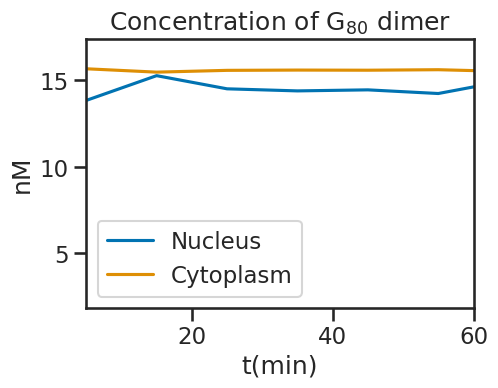

In [99]:
fig, ax = plt.subplots(figsize=(5,3.5))

ax.plot(deciTs[:60], nuclearConc[:60], label="Nucleus")
ax.plot(deciTs[:60], cytoConc[:60], label="Cytoplasm")
# ax.set(xlim=(deciTs[0], deciTs[-1]), xlabel="t(min)", ylabel="nM")
ax.set(xlim=(deciTs[0], 60), xlabel="t(min)", ylabel="nM")
ax.legend()
ax.title.set_text("Concentration of G$_{80}$ dimer")
# add annotation to the plot

# fig.tight_layout()
plt.savefig('G80_concentration.png',dpi=300,bbox_inches='tight')

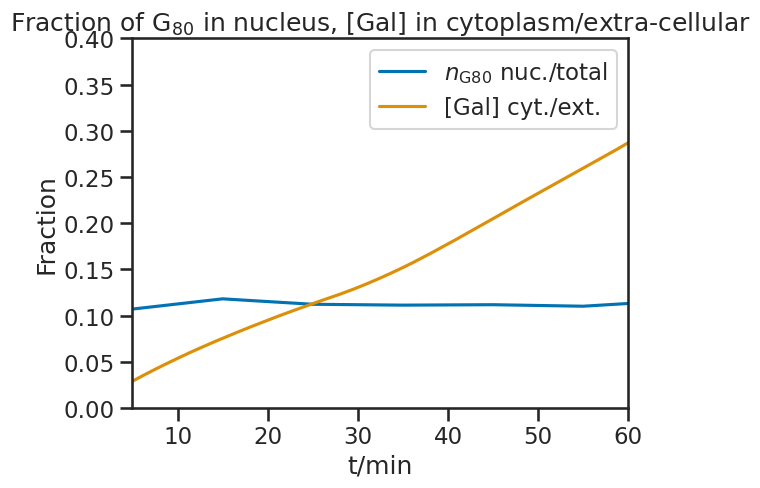

In [100]:
# fig, ax = plt.subplots(figsize=(5,3.5))
fig, ax = plt.subplots()
ax.plot(deciTs, nuclearFraction, label="$n_{\mathrm{G80}}$ nuc./total")
ax.plot(odeTs, 1e3*odeYs["GAI"]/NAV/11.1, label="[Gal] cyt./ext.")
# ax.set(xlim=(deciTs[0], deciTs[-1]), ylim=(0,0.4), xlabel="t/min", ylabel="Fraction")
ax.set(xlim=(deciTs[0], 60), ylim=(0,0.4), xlabel="t/min", ylabel="Fraction")
ax.legend()
ax.title.set_text("Fraction of G$_{80}$ in nucleus, [Gal] in cytoplasm/extra-cellular")
# fig.tight_layout()
fig.savefig('fraction.png',dpi=300,bbox_inches='tight')

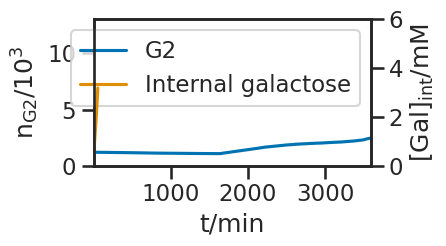

In [88]:
fig, ax = plt.subplots(figsize=(0.8*6,0.8*3.5))
ax2 = ax.twinx()
#ax.plot(deciTs, nuclearFraction, label="$n_{\mathrm{G80}}$ nuc./total")

nmemg2 = rdmePerCompartment['G2']['plasmaMembrane']['number']
_, nmemg2 = boxcar(rdmeTs, nmemg2, deci)
colors = sns.color_palette()

g2plot = ax.plot(deciTs, nmemg2/1e3, c=colors[0])[0]
gaiplot = ax2.plot(odeTs, 1e3*odeYs["GAI"]/NAV, c=colors[1])[0]
ax.set(xlim=(deciTs[0], deciTs[-1]), xlabel="t/min")
ax2.set(xlim=(deciTs[0], deciTs[-1]), xlabel="t/min")
ax2.set(ylabel=r"[Gal]$_{\mathrm{int}}$/mM", ylim=(0,6))
ax.set(ylabel=r"n$_{\mathrm{G2}}$/$10^{3}$", ylim=(0,13))
ax.legend([g2plot,gaiplot], ["G2", "Internal galactose"])
fig.tight_layout()

In [89]:
from scipy.ndimage.filters import gaussian_filter

In [90]:
traj.reg.nucleoplasm.volume/traj.reg.cytoplasm.volume

0.13586864233905024

In [91]:
total = (rdmePerCompartment['R2']['nucleoplasm']['number']
        +rdmePerCompartment['R2']['cytoplasm']['number']
        +rdmePerCompartment['R2']['ribosomes']['number']
        +rdmePerCompartment['ribosomeG2']['ribosomes']['number'])

[[328]]


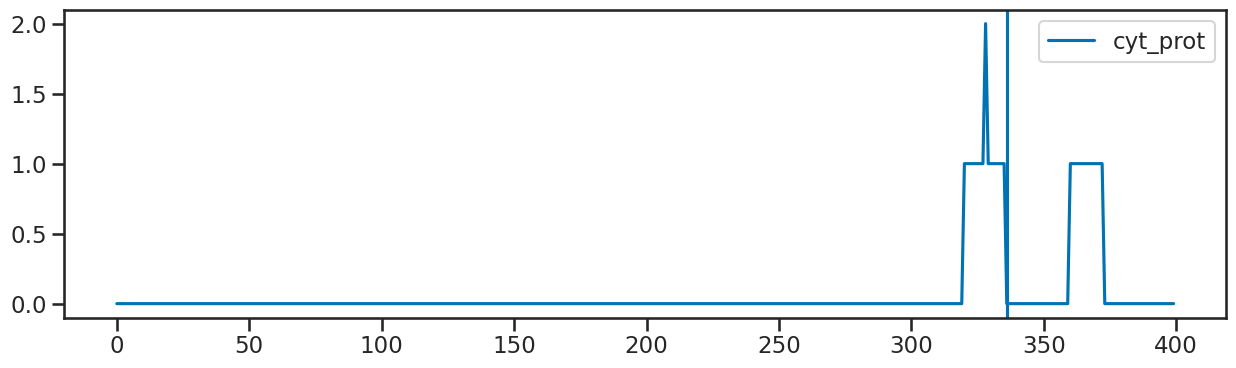

In [92]:
mrnaNuc = rdmePerCompartment['R2']['nucleoplasm']['number']
mrnaCyt = rdmePerCompartment['R2']['cytoplasm']['number']
mrnaRib = rdmePerCompartment['R2']['ribosomes']['number']
mrnaTrans = rdmePerCompartment['ribosomeG2']['ribosomes']['number']
protTrans = rdmePerCompartment['G2']['ribosomes']['number'] + rdmePerCompartment['G2']['cytoplasm']['number']
fig, ax = plt.subplots(figsize=(15,4))

birthIdx = np.where(mrnaNuc>0)[0][0]
cytIdx = np.where(mrnaCyt>0)[0][0]
ribIdx = np.where(mrnaTrans>0)[0][0]

didx = max(birthIdx,cytIdx,ribIdx)-min(birthIdx,cytIdx,ribIdx)
w = didx//4
i0 = 32100
i1 = 32500


pr = protTrans - protTrans[i0]
protIdx = np.where(pr[i0:]>0)[0][0] + i0


#ax.plot(rdmeTs[i0:i1],mrnaNuc[i0:i1])
#ax.plot(rdmeTs[i0:i1],mrnaCyt[i0:i1])
#ax.plot(rdmeTs[i0:i1],mrnaRib[i0:i1])
#ax.plot(rdmeTs[i0:i1],pr[i0:i1])
#ax.plot(np.mgrid[i0:i1],total[i0:i1], label='mRNA')
ax.plot(protTrans[i0:i1], label='cyt_prot')
print(np.argwhere(protTrans[i0:i1]==2))
#ax.plot(np.mgrid[i0:i1], mrnaTrans[i0:i1], label='rib')
#ax.plot(np.mgrid[i0:i1], rdmePerCompartment['R2']['cytoplasm']['number'][i0:i1], label='cyt_mrna')
ax.legend()
ax.axvline(336)
#ax.plot(rdmeTs[i0:i1],mrnaTrans[i0:i1])

In [93]:
break

SyntaxError: 'break' outside loop (668683560.py, line 4)

In [ ]:
total = 
mrnaNuc = rdmePerCompartment['R2']['nucleoplasm']['number']

In [ ]:
i1-i0,rdmeTs[i0],rdmeTs[i1]

(400, 1605.0000079996771, 1625.0000439996711)

In [ ]:

32100 + 296 - 60 - i0

5

In [ ]:
i0, i1

(32331, 32442)